In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
words = open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:   
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [9]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [10]:
C = torch.randn(27,2)

In [11]:
C

tensor([[-1.1382, -1.1455],
        [ 0.2327, -0.4697],
        [ 1.2195, -0.8613],
        [ 0.9431, -0.2007],
        [ 1.5882,  0.2007],
        [ 0.2703,  0.4087],
        [-2.3124,  0.1084],
        [-0.0973, -2.8082],
        [ 0.7481, -0.7905],
        [-1.4463,  0.0183],
        [-1.6793,  0.8211],
        [ 0.2921, -0.8244],
        [ 0.6220, -0.1195],
        [ 1.1879, -1.5690],
        [ 0.7017,  0.0397],
        [-0.7240, -0.6510],
        [-0.3464,  0.7100],
        [ 1.9436,  1.0100],
        [ 1.3577, -0.8389],
        [ 0.8283,  0.2543],
        [-1.1149, -0.2691],
        [-0.3147, -1.4396],
        [-0.5222,  1.5123],
        [ 2.0050, -0.6811],
        [ 1.5098,  0.2807],
        [-0.0963,  0.7526],
        [-1.8028,  0.9516]])

In [17]:
C.shape

torch.Size([27, 2])

In [18]:
C[5]

tensor([0.2703, 0.4087])

In [19]:
F.one_hot(torch.tensor(5),num_classes = 27)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [20]:
F.one_hot(torch.tensor(5),num_classes = 27).float() @ C

tensor([0.2703, 0.4087])

In [21]:
emb = C[X]
emb

tensor([[[-1.1382, -1.1455],
         [-1.1382, -1.1455],
         [-1.1382, -1.1455]],

        [[-1.1382, -1.1455],
         [-1.1382, -1.1455],
         [ 0.2703,  0.4087]],

        [[-1.1382, -1.1455],
         [ 0.2703,  0.4087],
         [ 1.1879, -1.5690]],

        [[ 0.2703,  0.4087],
         [ 1.1879, -1.5690],
         [ 1.1879, -1.5690]],

        [[ 1.1879, -1.5690],
         [ 1.1879, -1.5690],
         [ 0.2327, -0.4697]],

        [[-1.1382, -1.1455],
         [-1.1382, -1.1455],
         [-1.1382, -1.1455]],

        [[-1.1382, -1.1455],
         [-1.1382, -1.1455],
         [-0.7240, -0.6510]],

        [[-1.1382, -1.1455],
         [-0.7240, -0.6510],
         [ 0.6220, -0.1195]],

        [[-0.7240, -0.6510],
         [ 0.6220, -0.1195],
         [-1.4463,  0.0183]],

        [[ 0.6220, -0.1195],
         [-1.4463,  0.0183],
         [-0.5222,  1.5123]],

        [[-1.4463,  0.0183],
         [-0.5222,  1.5123],
         [-1.4463,  0.0183]],

        [[-0.5222,  1

In [22]:
emb.shape

torch.Size([32, 3, 2])

In [23]:
W1 = torch.randn(6,100)
b1 = torch.randn(100)

In [24]:
# emb @ W1 + b1
# emb [32, 3, 2]  W1 [6, 100]
# [32, 100]

In [25]:
emb.view(32,6)

tensor([[-1.1382, -1.1455, -1.1382, -1.1455, -1.1382, -1.1455],
        [-1.1382, -1.1455, -1.1382, -1.1455,  0.2703,  0.4087],
        [-1.1382, -1.1455,  0.2703,  0.4087,  1.1879, -1.5690],
        [ 0.2703,  0.4087,  1.1879, -1.5690,  1.1879, -1.5690],
        [ 1.1879, -1.5690,  1.1879, -1.5690,  0.2327, -0.4697],
        [-1.1382, -1.1455, -1.1382, -1.1455, -1.1382, -1.1455],
        [-1.1382, -1.1455, -1.1382, -1.1455, -0.7240, -0.6510],
        [-1.1382, -1.1455, -0.7240, -0.6510,  0.6220, -0.1195],
        [-0.7240, -0.6510,  0.6220, -0.1195, -1.4463,  0.0183],
        [ 0.6220, -0.1195, -1.4463,  0.0183, -0.5222,  1.5123],
        [-1.4463,  0.0183, -0.5222,  1.5123, -1.4463,  0.0183],
        [-0.5222,  1.5123, -1.4463,  0.0183,  0.2327, -0.4697],
        [-1.1382, -1.1455, -1.1382, -1.1455, -1.1382, -1.1455],
        [-1.1382, -1.1455, -1.1382, -1.1455,  0.2327, -0.4697],
        [-1.1382, -1.1455,  0.2327, -0.4697, -0.5222,  1.5123],
        [ 0.2327, -0.4697, -0.5222,  1.5

In [26]:
# 32,3,2
h = emb.view(-1,6) @ W1 + b1

In [27]:
h.shape

torch.Size([32, 100])

In [28]:
h

tensor([[-1.6897e+00,  4.2124e+00, -1.2975e+00,  ...,  7.2206e+00,
          3.3108e+00, -6.6001e+00],
        [-3.4662e+00,  3.8312e+00, -4.5687e+00,  ...,  5.1246e+00,
          5.1793e+00, -3.9897e+00],
        [-1.0288e+00,  3.3022e+00, -1.2534e+00,  ..., -1.0712e+00,
          2.6680e+00, -5.2099e+00],
        ...,
        [-1.2456e+00,  1.5927e+00, -2.2224e+00,  ...,  3.0525e-03,
          1.1693e+00, -2.5014e+00],
        [ 2.8485e+00, -2.5544e-02,  5.3062e-01,  ...,  1.8995e+00,
         -1.1037e+00, -3.1823e+00],
        [-4.1944e-01, -3.8879e-01, -8.4748e-01,  ...,  4.7606e+00,
          3.0059e+00,  1.2588e+00]])

In [29]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

In [30]:
h.shape

torch.Size([32, 100])

In [31]:
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [32]:
# h [32,100] W2 [100,27]
# [32,27]

In [33]:
logits = h @ W2 + b2

In [34]:
logits.shape

torch.Size([32, 27])

In [35]:
logits[0]

tensor([  4.0002,  -3.3650,   4.2140,  -3.1849, -11.3774,  -1.6161,  -0.6953,
         11.3083,  -8.2031,   0.1119,  -7.6938,   1.2376,   1.7433,   4.3534,
          5.2842,   0.9674, -11.7697,  -9.8026,   9.4010,  -2.8673,  -2.0508,
        -11.3652,  -4.9809,  -2.3740,   8.9623,  -2.0490,  -7.4053])

In [36]:
prob = logits.exp() / logits.exp().sum(1, keepdims = True)

In [37]:
prob[1].sum()

tensor(1.)

In [38]:
prob

tensor([[5.3635e-04, 3.3947e-07, 6.6420e-04, 4.0647e-07, 1.1248e-10, 1.9513e-06,
         4.9004e-06, 8.0047e-01, 2.6894e-09, 1.0985e-05, 4.4752e-09, 3.3858e-05,
         5.6141e-05, 7.6359e-04, 1.9368e-03, 2.5842e-05, 7.5980e-11, 5.4323e-10,
         1.1884e-01, 5.5839e-07, 1.2634e-06, 1.1386e-10, 6.7458e-08, 9.1445e-07,
         7.6645e-02, 1.2657e-06, 5.9720e-09],
        [3.0560e-06, 9.5184e-04, 1.4094e-02, 4.5706e-07, 1.3408e-05, 1.1984e-03,
         4.1525e-07, 1.5755e-01, 2.1094e-07, 1.7602e-08, 2.9756e-09, 2.2713e-06,
         8.8665e-04, 7.6259e-01, 5.3485e-02, 1.6632e-06, 1.7129e-10, 1.4498e-10,
         1.5342e-04, 8.5352e-03, 8.0841e-05, 4.6496e-12, 1.2904e-08, 4.0982e-06,
         4.5131e-04, 9.8080e-07, 7.9257e-10],
        [4.8554e-10, 9.5604e-11, 2.6303e-03, 1.1126e-04, 1.6513e-11, 1.3808e-03,
         2.5317e-11, 1.8130e-05, 1.2655e-06, 1.9601e-12, 3.9669e-11, 8.9148e-01,
         1.1702e-10, 4.4800e-07, 2.3939e-09, 1.1086e-07, 2.6247e-10, 1.0827e-14,
         2.1232e-

In [39]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [40]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [41]:
prob[torch.arange(32), Y]

tensor([1.9513e-06, 7.6259e-01, 4.4800e-07, 4.7857e-08, 5.5239e-11, 2.5842e-05,
        2.0023e-04, 1.1566e-07, 1.1523e-03, 4.1602e-09, 1.8082e-07, 1.1028e-05,
        3.3947e-07, 4.4517e-08, 2.3188e-03, 1.5620e-04, 1.0985e-05, 2.2061e-05,
        5.7608e-06, 1.1375e-03, 2.3352e-09, 1.1466e-07, 5.7795e-12, 9.3012e-10,
        3.3349e-09, 5.5839e-07, 1.1411e-07, 1.1451e-05, 2.5941e-08, 1.6811e-10,
        1.4121e-09, 4.3197e-04])

In [42]:
-prob[torch.arange(32), Y].log().mean()

tensor(14.2536)

In [118]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,100), generator = g)
b1 = torch.randn(100 , generator = g)
W2 = torch.randn((100,27), generator = g)
b2 = torch.randn(27 , generator = g)
parameters = [C, W1, b1, W2, b2]

In [55]:
sum(p.nelement() for p in parameters) # total number of params in our model

3481

In [56]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 
prob = logits.exp() / logits.exp().sum(1, keepdims = True)
loss = -prob[torch.arange(32), Y].log().mean()
loss


tensor(17.7697)

In [64]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,100), generator = g)
b1 = torch.randn(100 , generator = g)
W2 = torch.randn((100,27), generator = g)
b2 = torch.randn(27 , generator = g)
parameters = [C, W1, b1, W2, b2]

In [65]:
sum(p.nelement() for p in parameters) # total number of params in our model

3481

In [66]:
for p in parameters:
    p.requires_grad = True

In [70]:
for _ in range(100):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.1 * p.grad

0.2678886950016022
0.2678229808807373
0.26775774359703064
0.26769310235977173
0.267628937959671
0.2675652801990509
0.267502099275589
0.2674393951892853
0.26737719774246216
0.267315536737442
0.2672543227672577
0.2671935260295868
0.2671332359313965
0.2670733630657196
0.2670140266418457
0.26695507764816284
0.2668965756893158
0.2668384909629822
0.26678091287612915
0.26672372221946716
0.2666669487953186
0.2666105628013611
0.26655468344688416
0.2664991617202759
0.26644399762153625
0.26638928055763245
0.26633498072624207
0.26628100872039795
0.26622751355171204
0.26617431640625
0.2661215364933014
0.2660691440105438
0.2660171091556549
0.26596540212631226
0.2659141421318054
0.26586320996284485
0.26581260561943054
0.2657623887062073
0.26571252942085266
0.2656629681587219
0.26561373472213745
0.265564888715744
0.26551634073257446
0.26546818017959595
0.2654203176498413
0.26537278294563293
0.26532554626464844
0.2652786374092102
0.26523205637931824
0.26518580317497253
0.26513978838920593
0.26509416103

In [ ]:
# we are just talking about 5 words and 32 examples

In [71]:
logits.max(1)

torch.return_types.max(
values=tensor([12.5147, 16.1859, 19.9331, 19.5513, 15.5963, 12.5147, 14.9062, 13.2860,
        15.0078, 17.1498, 14.7097, 19.7565, 12.5147, 15.7185, 15.9862, 18.8103,
        12.5147, 15.4781, 13.8118, 15.7347, 17.5781, 14.7050,  9.7818,  9.7048,
        14.8212, 12.5147, 15.2217, 15.8895, 12.0754, 15.4487, 17.8327, 14.5365],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [72]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [75]:
# build the dataset
block_size = 3 
X, Y = [], []
for w in words:   
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [131]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,100), generator = g)
b1 = torch.randn(100 , generator = g)
W2 = torch.randn((100,27), generator = g)
b2 = torch.randn(27 , generator = g)
parameters = [C, W1, b1, W2, b2]

In [132]:
sum(p.nelement() for p in parameters) # total number of params in our model

3481

In [133]:
for p in parameters:
    p.requires_grad = True

In [124]:
for _ in range(10):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Y)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

11.051855087280273


In [125]:
# it will take a bit of time for each iteration

In [126]:
X.shape

torch.Size([228146, 3])

In [127]:
torch.randint(0,5,(32,))

tensor([1, 3, 2, 4, 2, 0, 2, 2, 0, 0, 4, 4, 1, 1, 3, 1, 1, 4, 4, 4, 1, 1, 1, 4,
        4, 0, 0, 4, 3, 3, 0, 2])

In [128]:
ix = torch.randint(0,X.shape[0],(32,))

In [129]:
C[X[ix]]

tensor([[[ 1.1476, -0.4602],
         [-1.3922, -0.2169],
         [ 0.0902, -1.0768]],

        [[ 1.1476, -0.4602],
         [ 0.0902, -1.0768],
         [-1.1359,  0.2431]],

        [[ 1.1476, -0.4602],
         [ 1.1476, -0.4602],
         [ 1.1476, -0.4602]],

        [[-1.4566,  0.3174],
         [ 0.0902, -1.0768],
         [ 0.4350, -0.7086]],

        [[-0.4806,  0.5774],
         [ 2.3819, -0.6509],
         [-1.0588,  0.6867]],

        [[ 1.1476, -0.4602],
         [ 1.1476, -0.4602],
         [ 0.2610, -0.0779]],

        [[-1.7518,  1.0458],
         [-1.7518,  1.0458],
         [-1.0588,  0.6867]],

        [[ 1.1476, -0.4602],
         [ 1.1476, -0.4602],
         [ 1.1476, -0.4602]],

        [[-1.4566,  0.3174],
         [ 1.4994, -1.5578],
         [ 0.0902, -1.0768]],

        [[ 1.1476, -0.4602],
         [-1.7518,  1.0458],
         [-1.3922, -0.2169]],

        [[ 0.0622,  0.8087],
         [-1.7518,  1.0458],
         [ 0.4350, -0.7086]],

        [[ 0.0902, -1

In [154]:
for _ in range(10000):

    # mini batch construction
    ix = torch.randint(0,X.shape[0],(32,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.00001 * p.grad

print(loss.item())


2.424943685531616


In [ ]:
# since we are doing mini batches, the quality of our gradient is lower
# its better to have approx gradient and take more steps
# rather than to evaluate exact gradient and take fewer steps

In [155]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Y)
loss


tensor(2.3755, grad_fn=<NllLossBackward0>)

In [ ]:
# this model is very small with close to 3k params, models can have millions or billions of param
# as the capacity of the neural network grows, it becomes more and more capable of overfitting the training set
# the loss on training set might become close to 0 and all what model is doing is memorizing all the examples it saw
# when we sample we get same names as the training set
# split the dataset into 3 splits (training, val/dev, test)
# 80% , 10%, 10%

In [289]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [198]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,100), generator = g)
b1 = torch.randn(100 , generator = g)
W2 = torch.randn((100,27), generator = g)
b2 = torch.randn(27 , generator = g)
parameters = [C, W1, b1, W2, b2]

In [199]:
sum(p.nelement() for p in parameters) # total number of params in our model

3481

In [200]:
for p in parameters:
    p.requires_grad = True

In [210]:
for _ in range(10000):

    # mini batch construction
    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.01 * p.grad

print(loss.item())

3.0170483589172363


In [211]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3595, grad_fn=<NllLossBackward0>)

In [212]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3600, grad_fn=<NllLossBackward0>)

In [ ]:
# the loss on full training data and dev data are almost same, we are not overfitting.
# this model is not powerful enough to memorize things.
# that means our network is small, we can expect to make improvements by scaling up the size.

In [225]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,300), generator = g)
b1 = torch.randn(300 , generator = g)
W2 = torch.randn((300,27), generator = g)
b2 = torch.randn(27 , generator = g)
parameters = [C, W1, b1, W2, b2]

In [226]:
sum(p.nelement() for p in parameters) # total number of params in our model

10281

In [227]:
for p in parameters:
    p.requires_grad = True

In [248]:
for _ in range(10000):

    # mini batch construction
    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.001 * p.grad

print(loss.item())

1.9609144926071167


In [249]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2867, grad_fn=<NllLossBackward0>)

In [250]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2910, grad_fn=<NllLossBackward0>)

In [251]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))


carlah.
amerle.
khi.
mili.
thaydencansa.
jazheen.
deliah.
jareei.
nelinia.
chaiiv.
kaleigh.
ham.
join.
quian.
sroilea.
jadbi.
watelo.
dearyni.
jaceelinsan.
edde.


In [ ]:
# since we have the embedding of 2, it might be a bottleneck

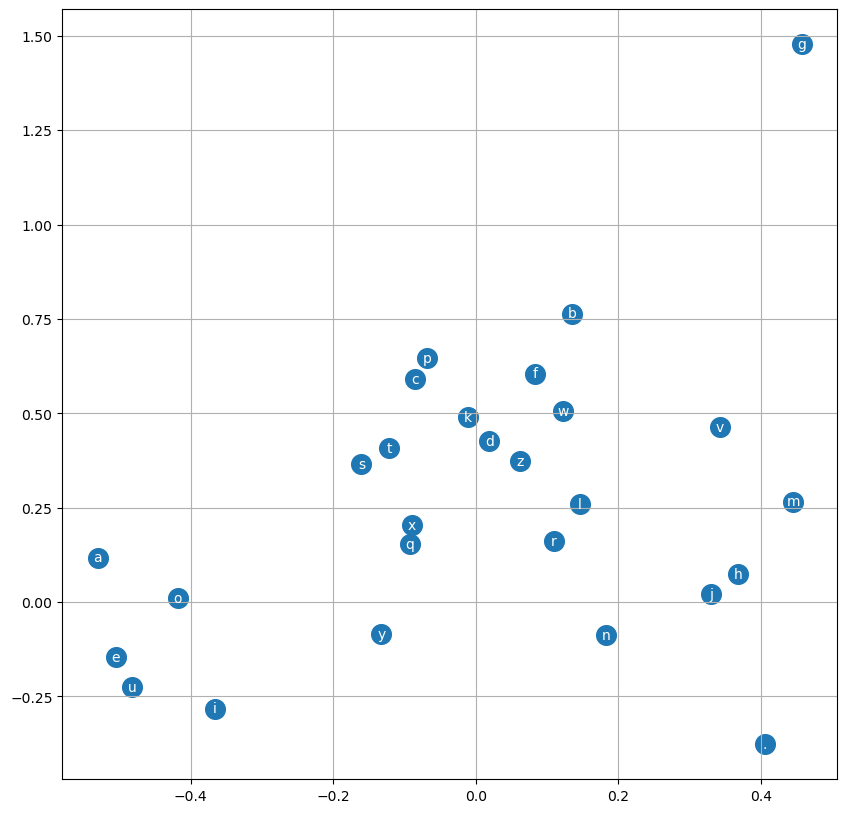

In [252]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(10,10))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.show()

In [253]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator = g)
W1 = torch.randn((30,300), generator = g)
b1 = torch.randn(300 , generator = g)
W2 = torch.randn((300,27), generator = g)
b2 = torch.randn(27 , generator = g)
parameters = [C, W1, b1, W2, b2]

In [254]:
sum(p.nelement() for p in parameters) # total number of params in our model

17697

In [255]:
for p in parameters:
    p.requires_grad = True

In [269]:
for _ in range(10000):

    # mini batch construction
    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.01 * p.grad

print(loss.item())

2.1581404209136963


In [270]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2435, grad_fn=<NllLossBackward0>)

In [271]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2700, grad_fn=<NllLossBackward0>)

In [272]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,100), generator = g)
W1 = torch.randn((300,500), generator = g)
b1 = torch.randn(500 , generator = g)
W2 = torch.randn((500,27), generator = g)
b2 = torch.randn(27 , generator = g)
parameters = [C, W1, b1, W2, b2]

In [273]:
sum(p.nelement() for p in parameters) # total number of params in our model

166727

In [274]:
for p in parameters:
    p.requires_grad = True

In [283]:
for _ in range(10000):

    # mini batch construction
    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,300) @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.001 * p.grad

print(loss.item())

1.7620368003845215


In [284]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,300) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0437, grad_fn=<NllLossBackward0>)

In [285]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,300) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2186, grad_fn=<NllLossBackward0>)

In [286]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
ambrilli.
kimri.
reity.
skaasha.
jazzuha.
delynn.
jareei.
ner.
kiah.
maiir.
kaleigh.
ham.
join.
quinthonova.
alian.
quinte.
madiaryn.
kai.
eveigh.
